# Lab 2 (simplified) · Part 2 — Inside the model: opening the black box
### EUROCONTROL AI Lab · Exercise 2S-2

In Part 1 we trained a small neural network that gives the probability of **visibility below 1 500 m at Malpensa 3 hours from now**
(our proxy for Low-Visibility Procedures). The model is often called a *black box*. In this notebook we open it:

- **Part A — What the model really is:** we draw the network, look at every one of its numbers, and follow one prediction step by step.
- **Part B — Why did it say that?** Simple *explainability* methods that look at the model from the outside: which inputs matter, what happens
  if we change them, and why the model raised (or did not raise) one particular alert.

| | |
|---|---|
| ⏱ **Time** | about 1 hour |
| 🎓 **Prerequisites** | Part 1 (it saves the trained model in the `artifacts` folder). A ready-trained copy is included, so this part also works on its own. |

**What you will learn**
1. A neural network is just a few hundred numbers (the **weights**) combined with multiplications, additions and a simple on/off rule.
2. What the **activations** of the neurons are: how strongly each neuron reacts to one particular hour — and how some neurons become *detectors* of a weather situation.
3. Why reading those numbers directly does not tell us *why* the model decides something.
4. Three simple ways to **explain** a model: importance of the inputs, "what-if" curves, and the explanation of a single alert.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

>
> 🧑‍💻 **Optional coding challenges** — a few cells invite those who want to **write code** to try a variation of the exercise.
> They are clearly marked, **switched off** (every line starts with `#`, so running them does nothing) and the rest of the notebook does not depend on them: skip them freely.
> To try one, remove the `#` signs (select the lines and press **Ctrl + /**, or **Cmd + /** on a Mac), fill in the `___` blanks and run the cell.
> The solutions are in the `solutions` folder next to this notebook.

> ✅ **SOLUTIONS NOTEBOOK** — identical to the participant notebook, except that the **optional coding challenges** (🧑‍💻) are solved and executed. Search for 🧑‍💻 to jump to them.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab2s_low_visibility_simple/solutions/2S-2_inside_the_model_SOLUTIONS.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab2s_low_visibility_simple/solutions")# work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup: load the trained model and the data

In [2]:
import sys                                        # sys: lets Python find our shared file
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import seaborn as sns                             # seaborn: heatmaps
import torch                                      # PyTorch: neural networks

LAB_DIR = Path(".").resolve()                     # this lab's folder (as a full path)...
if not (LAB_DIR / "lowvis_core.py").exists():     # ...or, from the solutions folder...
    LAB_DIR = LAB_DIR.parent                      # ...the folder above
DATA_DIR = LAB_DIR.parent / "data"                # the data folder, next to this lab's folder
sys.path.insert(0, str(LAB_DIR))                  # let Python find lowvis_core.py
import lowvis_core                                # the shared code of this lab (same definitions as Part 1)

saved = lowvis_core.SavedModel(LAB_DIR / "artifacts")   # load the model trained and saved in Part 1
model = saved.model                               # the neural network itself
FEATURES = lowvis_core.FEATURES                   # the names of the 8 inputs
NAMES = lowvis_core.FEATURE_NAMES                 # their readable names
READABLE = []                                     # the readable names, in the same order as FEATURES
for f in FEATURES:                                # for each input...
    READABLE.append(NAMES[f])                     # ...add its readable name

weather = lowvis_core.load_weather(DATA_DIR / "LIMC.csv")          # the hourly weather reports, in aviation units
features = lowvis_core.build_features(weather, weather.index)      # the 8 inputs of every hour
dataset = features.copy()                         # copy the inputs...
dataset["target"] = lowvis_core.build_target(weather)              # ...add the target (low visibility 3 hours later)
dataset = dataset.dropna()                        # ...remove incomplete hours
test = dataset[dataset.index >= "2025-01-01"]     # the test year 2025

print("Model loaded:", saved.card["name"])        # which model
print("Alert threshold:", saved.threshold)        # its threshold

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

Model loaded: Low-visibility nowcast LIMC, simplified (LVP proxy)
Alert threshold: 0.5


---
# Part A — What the model really is

## 1 · The whole network in one picture
Every circle is a **neuron**, every line a **weight** — a number learned during training.
**Blue** lines are positive weights (they push the value up), **red** lines are negative (they push it down); thicker lines are larger numbers.

The whole model is 433 numbers


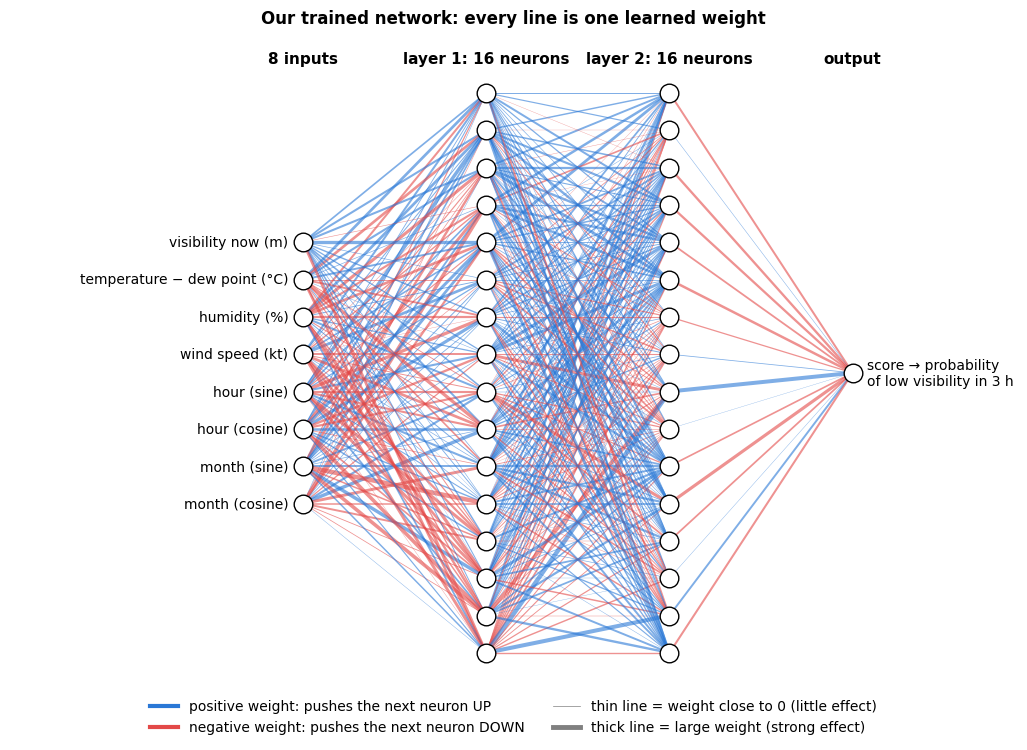

In [3]:
W1 = model.layer1.weight.detach().numpy()          # weights of layer 1: 16 rows (neurons) x 8 columns (inputs)
W2 = model.layer2.weight.detach().numpy()          # weights of layer 2: 16 x 16
W3 = model.output.weight.detach().numpy()          # weights of the output layer: 1 x 16
b1 = model.layer1.bias.detach().numpy()            # one extra number (bias) per neuron of layer 1
b2 = model.layer2.bias.detach().numpy()            # biases of layer 2
b3 = model.output.bias.detach().numpy()            # bias of the output

total = W1.size + W2.size + W3.size + b1.size + b2.size + b3.size   # count all the numbers
print("The whole model is", total, "numbers")      # show the total

layer_sizes = [8, 16, 16, 1]                       # neurons in each column of the drawing
weight_tables = [W1, W2, W3]                       # the connections between consecutive columns
largest = max(np.abs(W1).max(), np.abs(W2).max(), np.abs(W3).max())   # the largest weight, to scale line widths

def y_position(i, n):                              # vertical position of neuron i in a column of n neurons
    return (n - 1) / 2 - i                         # centred around 0

plt.figure(figsize=(13, 8))                        # new figure
for column in range(3):                            # for each group of connections (layer 1, 2, output)...
    table = weight_tables[column]                  # ...its weight table
    for j in range(table.shape[0]):                # for each neuron on the right side...
        for i in range(table.shape[1]):            # ...and each neuron on the left side:
            w = table[j, i]                        # the weight connecting them
            if w > 0:                              # positive weight...
                colour = PALETTE[0]                # ...blue
            else:                                  # negative weight...
                colour = PALETTE[7]                # ...red
            x_left = column                        # horizontal position of the left neuron
            x_right = column + 1                   # horizontal position of the right neuron
            y_left = y_position(i, layer_sizes[column])        # vertical position of the left neuron
            y_right = y_position(j, layer_sizes[column + 1])   # vertical position of the right neuron
            width = 0.2 + 3 * abs(w) / largest     # thicker line = larger weight
            plt.plot([x_left, x_right], [y_left, y_right], color=colour, linewidth=width, alpha=0.6)   # draw the line

for column in range(4):                            # draw the neurons of each column as circles
    for i in range(layer_sizes[column]):           # for each neuron of the column
        plt.scatter(column, y_position(i, layer_sizes[column]), s=180, color="white", edgecolor="black", zorder=3)   # a circle
for i in range(8):                                 # write the name of each input on the left
    plt.text(-0.08, y_position(i, 8), NAMES[FEATURES[i]], ha="right", va="center", fontsize=10)   # input name
plt.text(3.08, 0, "score → probability\nof low visibility in 3 h", ha="left", va="center", fontsize=10)   # output label
column_titles = ["8 inputs", "layer 1: 16 neurons", "layer 2: 16 neurons", "output"]   # titles of the columns
for column in range(4):                            # write the title above each column
    plt.text(column, 8.3, column_titles[column], ha="center", fontsize=11, fontweight="bold")   # column title
from matplotlib.lines import Line2D                # Line2D: lets us draw sample lines for the legend
legend_lines = [                                   # the entries of the legend:
    Line2D([0], [0], color=PALETTE[0], linewidth=3, label="positive weight: pushes the next neuron UP"),     # blue line
    Line2D([0], [0], color=PALETTE[7], linewidth=3, label="negative weight: pushes the next neuron DOWN"),   # red line
    Line2D([0], [0], color="grey", linewidth=0.5, label="thin line = weight close to 0 (little effect)"),    # thin line
    Line2D([0], [0], color="grey", linewidth=3.5, label="thick line = large weight (strong effect)"),        # thick line
]                                                  # (end of the legend entries)
plt.legend(handles=legend_lines, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=2, fontsize=10)   # legend below the drawing
plt.axis("off")                                    # no axes around the drawing
plt.xlim(-1.6, 3.9)                                # horizontal space for the labels
plt.title("Our trained network: every line is one learned weight", pad=30)   # title
plt.show()                                         # display

📖 **How to read the drawing:** information flows **from left to right**. Each line multiplies the value of the neuron on its left by its weight and passes it to the neuron on its right.
**Blue** = positive weight (a high value on the left pushes the right neuron up), **red** = negative weight (it pushes it down); the **thicker** the line, the larger the weight.
(Each neuron also has one extra number of its own, the *bias*, not drawn here.)

📖 **Reading:** this is the **entire** model: about 430 numbers. Nothing else is hidden inside. Every prediction is made by passing the 8 inputs through these lines,
from left to right. But even with the full picture in front of us, it is impossible to say *why* the model predicts fog — there are too many interacting lines.

## 2 · The three weight tables
The same numbers as in the drawing, now shown as three tables — one per group of lines. **Each coloured square is one weight**, and the colour scale on the right
tells you its value: **blue = positive**, **red = negative**, **white ≈ 0**. The three tables use the same colour scale, so colours can be compared.

| Table | Size | Meaning of one square |
|---|---|---|
| Layer 1 | **8 rows × 16 columns** = 128 weights | row = one input, column = one neuron of layer 1 |
| Layer 2 | **16 rows × 16 columns** = 256 weights | row = one neuron of layer 1, column = one neuron of layer 2 |
| Output | **16 rows × 1 column** = 16 weights | row = one neuron of layer 2, the single column = the output |

*A note on the output table:* PyTorch stores these 16 weights as **1 row × 16 columns** (one output, receiving 16 values). Here we draw them **turned on their side**, as a
column of 16, so that each square lines up with the neuron of layer 2 it comes from. It is the same 16 numbers.

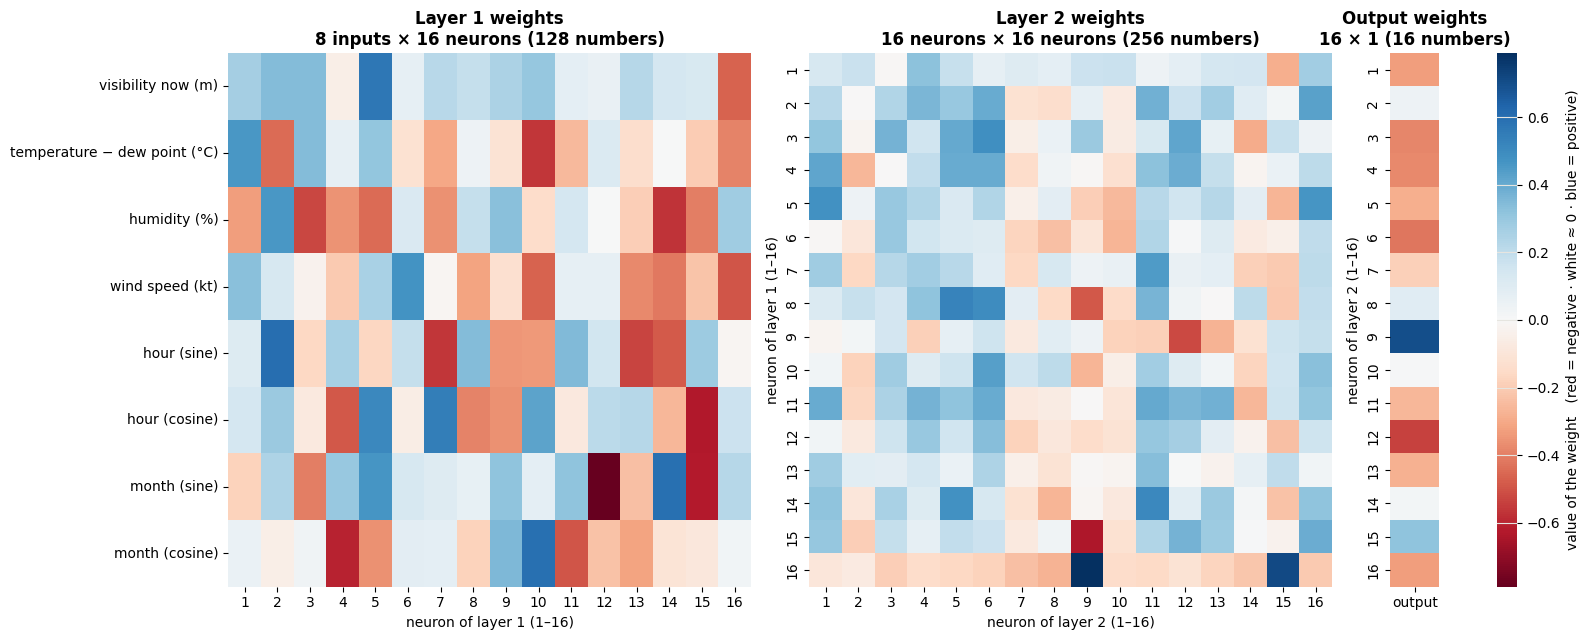

In [4]:
limit = max(np.abs(W1).max(), np.abs(W2).max(), np.abs(W3).max())   # the largest weight: the same colour scale for all tables
fig, axes = plt.subplots(1, 4, figsize=(16, 6.5), gridspec_kw={"width_ratios": [16, 16, 1.5, 0.6]})   # 3 tables + colour scale

sns.heatmap(W1.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[0], cbar=False,
            yticklabels=READABLE, xticklabels=range(1, 17))   # rows = the 8 inputs, columns = the 16 neurons of layer 1
axes[0].set_title("Layer 1 weights\n8 inputs × 16 neurons (128 numbers)")   # title with the size
axes[0].set_xlabel("neuron of layer 1 (1–16)")      # horizontal axis label

sns.heatmap(W2.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[1], cbar=False,
            yticklabels=range(1, 17), xticklabels=range(1, 17))   # rows = neurons of layer 1, columns = neurons of layer 2
axes[1].set_title("Layer 2 weights\n16 neurons × 16 neurons (256 numbers)")   # title with the size
axes[1].set_xlabel("neuron of layer 2 (1–16)")      # horizontal axis label
axes[1].set_ylabel("neuron of layer 1 (1–16)")      # vertical axis label

sns.heatmap(W3.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[2], cbar_ax=axes[3],
            yticklabels=range(1, 17), xticklabels=["output"],
            cbar_kws={"label": "value of the weight   (red = negative · white ≈ 0 · blue = positive)"})   # plus the colour scale
axes[2].set_title("Output weights\n16 × 1 (16 numbers)")   # title with the size
axes[2].set_ylabel("neuron of layer 2 (1–16)")      # vertical axis label

for ax in axes[:3]:                                # for each of the three tables...
    ax.grid(False)                                 # ...no grid lines
plt.tight_layout()                                 # adjust spacing
plt.show()                                         # display

📖 **Reading:**
- **Layer 1** is the only table whose rows have a **meaning we can name**: each row is a real input. We can see, for instance, which neurons react strongly to visibility or to humidity.
- **Layer 2** and the **output** connect *neurons to neurons*: "neuron 5 of layer 1" feeds "neuron 12 of layer 2". Neither side has a human meaning, so these colours cannot be read.
- After the first layer the meaning of the inputs is **mixed** together. That is why, to understand *why* a model decides something, we need methods that look at it
  **from the outside** — inputs in, prediction out. That is Part B.

## 3 · Following one prediction through the network
We take one real hour: **31 December 2022 at 20:50**, three hours before the fog of the New Year's Eve night (Part 1, §2.3).
Visibility is still 3 500 m, but in 3 hours it will be below 1 500 m.

In [5]:
HOUR = "2022-12-31 20:50"                          # the hour we follow
raw_inputs = features.loc[[HOUR]]                  # its 8 inputs (a table with one row)
print("Truth: low visibility 3 hours later?", int(dataset.loc[HOUR, "target"]))   # what really happened
raw_inputs.round(2)                                # display the raw inputs

Truth: low visibility 3 hours later? 1


,vis_m,spread_c,rh,wind_kt,hour_sin,hour_cos,month_sin,month_cos
valid,,,,,,,,
2022-12-31 20:50:00,3492.27,1.0,93.4,1.0,-0.87,0.5,-0.0,1.0


**Step 1 — scaling.** Each input is turned into *"how far from its usual value"*, using the averages and spreads of the training years (Part 1, §5).

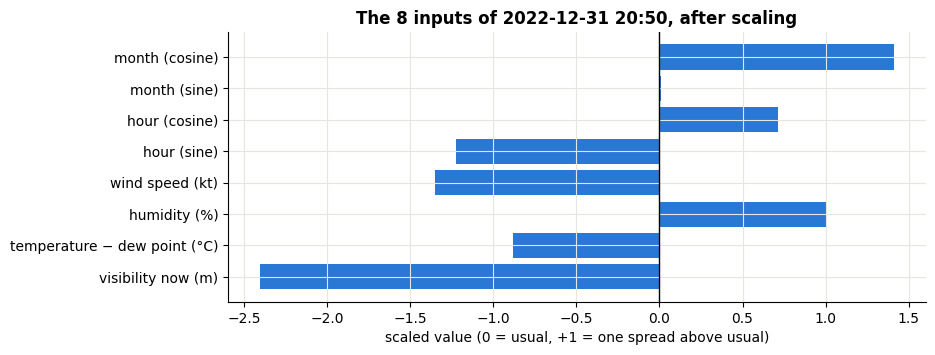

In [6]:
x = saved.scale(raw_inputs)[0]                     # the 8 scaled inputs (0 = the usual value)

plt.figure(figsize=(9, 3.5))                       # new figure
plt.barh(READABLE, x, color=PALETTE[0])   # one bar per input
plt.axvline(0, color="black", linewidth=1)         # the line of "usual value"
plt.xlabel("scaled value (0 = usual, +1 = one spread above usual)")   # axis label
plt.title("The 8 inputs of " + HOUR + ", after scaling")   # title
plt.show()                                         # display

📖 **Reading:** visibility is below its usual value, temperature − dew point is small (air close to saturation), and hour and month point to a winter night.

**Step 2 — layer by layer.** We now repeat by hand what the network does: *multiply by the weights, add the bias, apply ReLU* (negative values become 0).

> 💡 **What is an activation?** Every neuron does two small steps:
> 1. a **weighted sum** of the numbers it receives, plus its bias — for example *(visibility × −0.47) + (humidity × 0.28) + … − 0.27*;
> 2. **ReLU**: if the result is negative it becomes 0, otherwise it passes unchanged.
>
> The number that comes out is the neuron's **activation**: *how strongly this neuron reacts to this particular hour*. **0 means the neuron is silent.**
> The **weights are fixed** after training — the same for every hour. The **activations change with every hour**: they are what the network computes *about this hour*.

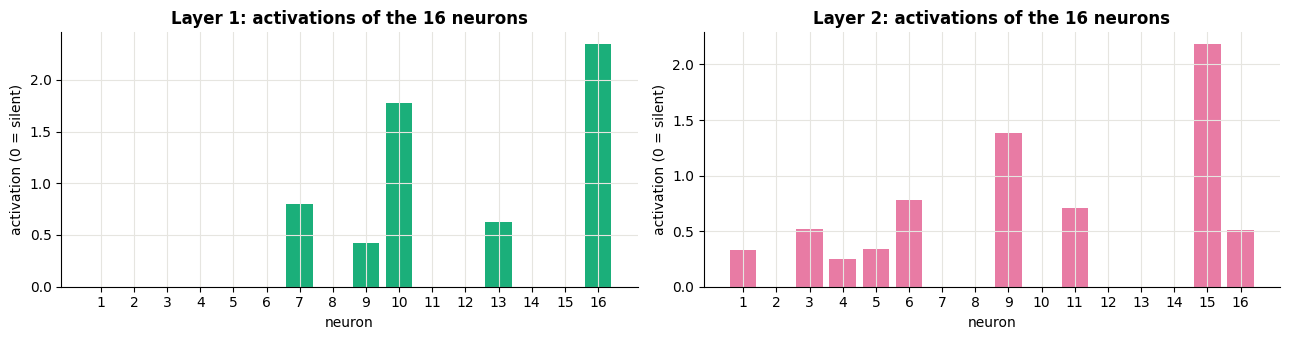

Output score: 0.289
Probability (by hand): 0.572
Probability (PyTorch): 0.572
→ ALERT


In [7]:
z1 = W1 @ x + b1                                   # layer 1: weighted sums of the 8 inputs (16 numbers); @ = "multiply by the table"
h1 = np.maximum(z1, 0)                             # ReLU: negative values become 0
z2 = W2 @ h1 + b2                                  # layer 2: weighted sums of the 16 values of layer 1
h2 = np.maximum(z2, 0)                             # ReLU again
score = float((W3 @ h2 + b3)[0])                   # output: one weighted sum of the 16 values of layer 2
probability = 1 / (1 + np.exp(-score))             # sigmoid: turns the score into a probability between 0 and 1

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))  # two plots side by side
axes[0].bar(range(1, 17), h1, color=PALETTE[2])    # activations of the 16 neurons of layer 1
axes[0].set_title("Layer 1: activations of the 16 neurons")   # title
axes[0].set_xlabel("neuron")                       # axis label
axes[0].set_ylabel("activation (0 = silent)")      # axis label
axes[0].set_xticks(range(1, 17))                   # show every neuron number
axes[1].bar(range(1, 17), h2, color=PALETTE[4])    # activations of the 16 neurons of layer 2
axes[1].set_title("Layer 2: activations of the 16 neurons")   # title
axes[1].set_xlabel("neuron")                       # axis label
axes[1].set_ylabel("activation (0 = silent)")      # axis label
axes[1].set_xticks(range(1, 17))                   # show every neuron number
plt.tight_layout()                                 # adjust spacing
plt.show()                                         # display

print("Output score:", round(score, 3))            # the raw score
print("Probability (by hand):", round(probability, 3))   # the probability we computed ourselves
print("Probability (PyTorch):", round(float(saved.probability(raw_inputs)[0]), 3))   # the same, computed by the model
if probability >= saved.threshold:                 # compare with the threshold...
    print("→ ALERT")                               # ...above: alert
else:                                              # ...below:
    print("→ no alert")                            # no alert

📖 **Reading:** each bar is the **activation** of one neuron for this hour. In layer 1 most neurons are **silent (exactly 0)**: ReLU has switched them off because their weighted sum was negative.
Only a few react — and one (neuron 16) reacts much more strongly than the others. Layer 2 reads these few active neurons, and the output reads layer 2.
Our hand calculation gives **exactly the same probability as PyTorch**: there is no magic, only multiplications and additions.

**Zoom on one neuron.** Take the most active neuron of layer 1 and compute its value term by term:

In [8]:
n = int(np.argmax(h1))                             # the neuron of layer 1 with the largest value
terms = pd.DataFrame()                             # a table of the calculation
terms["input"] = READABLE      # the inputs
terms["scaled value"] = x.round(3)                 # their scaled values
terms["weight"] = W1[n].round(3)                   # the weights of this neuron
terms["weight × value"] = (W1[n] * x).round(3)     # each product
print("Neuron", n + 1, "of layer 1")               # which neuron
print("sum of the products:", round(float(np.sum(W1[n] * x)), 3))    # the weighted sum
print("+ bias:", round(float(b1[n]), 3))           # plus the bias
print("= ", round(float(z1[n]), 3), " → after ReLU:", round(float(h1[n]), 3))   # the result, and after ReLU
terms                                              # display the table

Neuron 16 of layer 1
sum of the products: 2.615
+ bias: -0.273
=  2.342  → after ReLU: 2.342


,input,scaled value,weight,weight × value
0,visibility now (m),-2.407,-0.467,1.124
1,temperature − dew point (°C),-0.884,-0.393,0.347
2,humidity (%),1.003,0.280,0.281
3,wind speed (kt),-1.353,-0.500,0.676
4,hour (sine),-1.225,-0.018,0.022
5,hour (cosine),0.712,0.173,0.123
6,month (sine),0.006,0.228,0.001
7,month (cosine),1.413,0.029,0.040


📖 **Reading:** the last column shows *why* this neuron is so active: each positive product pushes its activation up, each negative one pushes it down.
Here the large positive contributions come from **low visibility**, a **small temperature − dew point** (air close to saturation) and **calm wind** —
the classic ingredients of fog. Keep this neuron in mind: we meet it again in §3.2.

### 3.1 · Same weights, different activations
We now give the **same network** (same 433 numbers) a completely different hour: a **clear summer afternoon**, 15 July 2025 at 14:50.

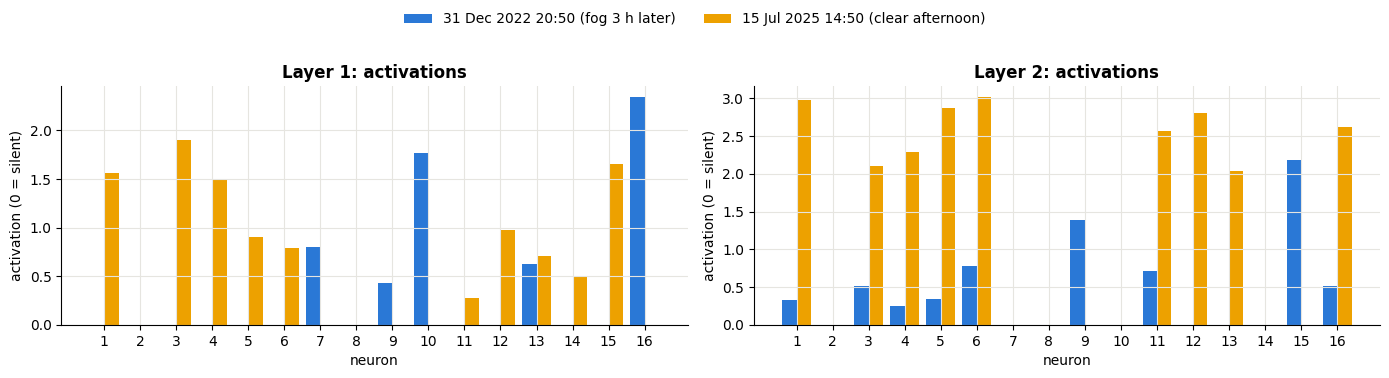

Active neurons in layer 1 — foggy evening: 5 · clear afternoon: 10
Neurons of layer 1 active in both hours: [13]
Probability — foggy evening: 0.572 · clear afternoon: 0.0002


In [9]:
def activations(raw_row):                          # the activations of both layers for one hour (raw inputs, one-row table)
    x_row = saved.scale(raw_row)[0]                # scale the 8 inputs
    a1 = np.maximum(W1 @ x_row + b1, 0)            # layer 1: weighted sums + bias, then ReLU
    a2 = np.maximum(W2 @ a1 + b2, 0)               # layer 2: the same, starting from layer 1
    return a1, a2                                  # give both back


CLEAR_HOUR = "2025-07-15 14:50"                    # a clear summer afternoon
fog_1, fog_2 = activations(features.loc[[HOUR]])   # activations for the foggy New Year's Eve evening
clear_1, clear_2 = activations(features.loc[[CLEAR_HOUR]])   # activations for the summer afternoon

neurons = np.arange(1, 17)                         # neuron numbers 1 ... 16
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))  # two plots side by side: layer 1 and layer 2
axes[0].bar(neurons - 0.2, fog_1, width=0.4, color=PALETTE[0], label="31 Dec 2022 20:50 (fog 3 h later)")   # foggy evening
axes[0].bar(neurons + 0.2, clear_1, width=0.4, color=PALETTE[3], label="15 Jul 2025 14:50 (clear afternoon)")   # clear afternoon
axes[0].set_title("Layer 1: activations")          # title
axes[1].bar(neurons - 0.2, fog_2, width=0.4, color=PALETTE[0], label="31 Dec 2022 20:50 (fog 3 h later)")   # foggy evening
axes[1].bar(neurons + 0.2, clear_2, width=0.4, color=PALETTE[3], label="15 Jul 2025 14:50 (clear afternoon)")   # clear afternoon
axes[1].set_title("Layer 2: activations")          # title
for ax in axes:                                    # for both plots...
    ax.set_xticks(neurons)                         # ...show every neuron number
    ax.set_xlabel("neuron")                        # ...axis label
    ax.set_ylabel("activation (0 = silent)")       # ...axis label
handles, labels = axes[0].get_legend_handles_labels()   # the two coloured bars and their names...
fig.legend(handles, labels, loc="upper center", ncol=2)  # ...one legend above both plots
plt.tight_layout(rect=[0, 0, 1, 0.88])             # adjust spacing, leaving room for the legend
plt.show()                                         # display

print("Active neurons in layer 1 — foggy evening:", int(np.sum(fog_1 > 0)), "· clear afternoon:", int(np.sum(clear_1 > 0)))   # how many react
both = []                                          # neurons active in BOTH hours
for i in range(16):                                # for each neuron of layer 1...
    if fog_1[i] > 0 and clear_1[i] > 0:            # ...if it reacts to both hours...
        both.append(i + 1)                         # ...remember its number
print("Neurons of layer 1 active in both hours:", both)   # the overlap
print("Probability — foggy evening:", round(float(saved.probability(features.loc[[HOUR]])[0]), 3),
      "· clear afternoon:", round(float(saved.probability(features.loc[[CLEAR_HOUR]])[0]), 4))   # the two answers

📖 **Reading:** the weights did not change at all, yet the two hours light up **almost completely different neurons**. In layer 1, five neurons react on the foggy evening
(neuron 16 most of all) and ten on the summer afternoon — and only neuron 13 is active in both. Neuron 16 is silent in summer. The **pattern of activations is the network's own description of the hour** —
and the output layer turns that description into a probability (57 % against almost 0 %).

### 3.2 · What does a neuron react to?
Neuron 16 was very active before the New Year's Eve fog and silent on the summer afternoon. Is that a coincidence? We compute the activations of layer 1
for **every hour of 2025** and compare two groups: the hours **followed by low visibility** 3 hours later, and all the other hours.

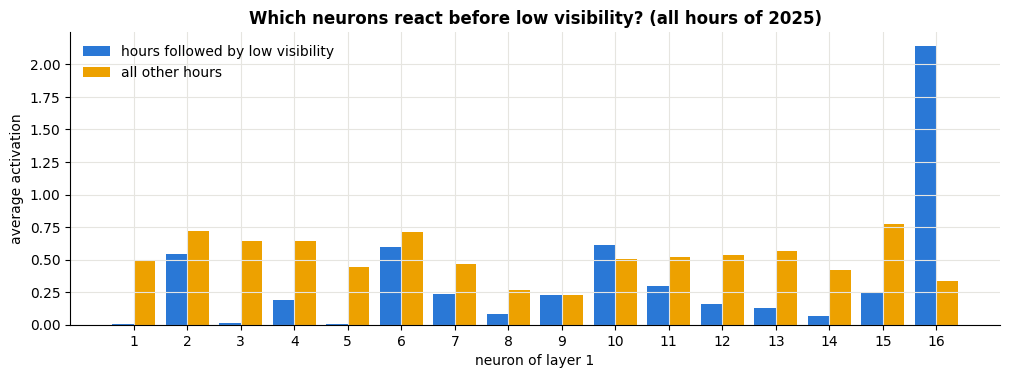

Neuron with the largest difference: neuron 16
Its weights (how much each input pushes it up or down) and its bias: -0.27


,input,weight
0,visibility now (m),-0.47
1,temperature − dew point (°C),-0.39
2,humidity (%),0.28
3,wind speed (kt),-0.50
4,hour (sine),-0.02
5,hour (cosine),0.17
6,month (sine),0.23
7,month (cosine),0.03


In [10]:
scaled_2025 = saved.scale(test[FEATURES])          # the scaled inputs of every hour of 2025 (a table: hours x 8)
layer1_2025 = np.maximum(scaled_2025 @ W1.T + b1, 0)   # layer-1 activations of every hour (hours x 16); W1.T = W1 turned so that it fits
before_low = test["target"].values == 1            # True for the hours followed by low visibility

mean_before_low = layer1_2025[before_low].mean(axis=0)   # average activation of each neuron in those hours
mean_other = layer1_2025[~before_low].mean(axis=0)       # average activation of each neuron in all other hours

plt.figure(figsize=(12, 3.8))                      # new figure
plt.bar(neurons - 0.2, mean_before_low, width=0.4, color=PALETTE[0], label="hours followed by low visibility")   # group 1
plt.bar(neurons + 0.2, mean_other, width=0.4, color=PALETTE[3], label="all other hours")   # group 2
plt.xticks(neurons)                                # show every neuron number
plt.xlabel("neuron of layer 1")                    # axis label
plt.ylabel("average activation")                   # axis label
plt.title("Which neurons react before low visibility? (all hours of 2025)")   # title
plt.legend()                                       # legend
plt.show()                                         # display

detector = int(np.argmax(mean_before_low - mean_other))   # the neuron with the largest difference between the two groups
print("Neuron with the largest difference: neuron", detector + 1)   # which one
print("Its weights (how much each input pushes it up or down) and its bias:", round(float(b1[detector]), 2))   # the bias
pd.DataFrame({"input": READABLE, "weight": W1[detector].round(2)})   # display its weights

📖 **Reading:** one neuron stands out — **neuron 16**: on average it is several times more active in the hours that come before low visibility than in the other hours.
Its weights explain why: **negative** for visibility, temperature − dew point and wind, **positive** for humidity. So it reacts when visibility is already reduced,
the air is moist and close to saturation and the wind is calm: it has become a **"fog-prone conditions" detector**. Nobody programmed this rule —
training created it because it helps to predict the target.

Let's watch this neuron during the New Year's Eve night, hour by hour, next to the visibility:

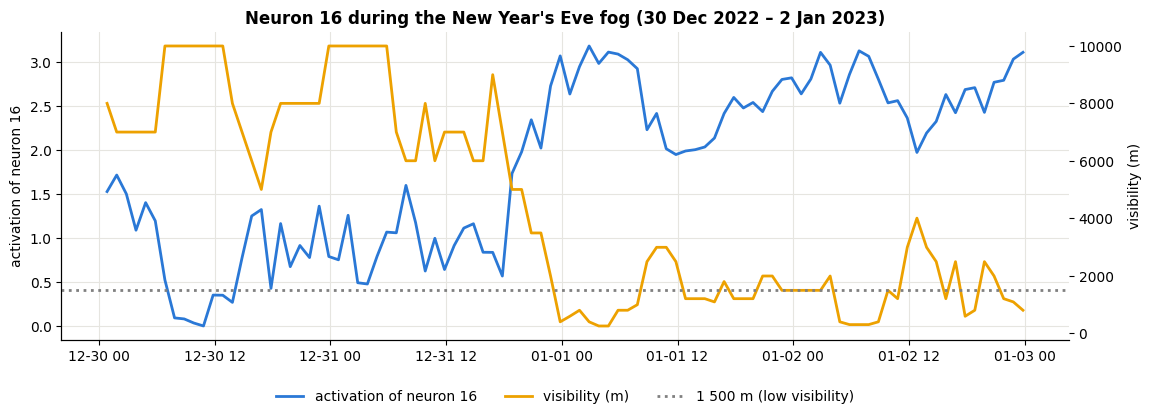

In [11]:
night = dataset.loc["2022-12-30":"2023-01-02"]     # four days around the New Year's Eve fog
night_layer1 = np.maximum(saved.scale(night[FEATURES]) @ W1.T + b1, 0)   # layer-1 activations of every hour

fig, ax1 = plt.subplots(figsize=(13, 4))           # new figure with a left axis
ax1.plot(night.index, night_layer1[:, detector], color=PALETTE[0], label="activation of neuron " + str(detector + 1))   # the detector
ax1.set_ylabel("activation of neuron " + str(detector + 1))   # left axis label
ax2 = ax1.twinx()                                  # a second vertical axis, on the right
ax2.plot(night.index, weather.loc[night.index, "visibility_m"], color=PALETTE[3], label="visibility (m)")   # the visibility
ax2.axhline(1500, color="grey", linestyle=":", label="1 500 m (low visibility)")   # the threshold of our target
ax2.set_ylabel("visibility (m)")                   # right axis label
ax2.grid(False)                                    # no second grid
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]    # the lines of both axes...
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]   # ...and their labels
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)   # one legend for everything, below the plot
ax1.set_title("Neuron " + str(detector + 1) + " during the New Year's Eve fog (30 Dec 2022 – 2 Jan 2023)")   # title
plt.show()                                         # display

📖 **Reading:** the activation of the neuron **rises in the evening of 31 December, while visibility is still above 1 500 m**, and stays high during the whole foggy period.
This is exactly what we want from a 3-hour warning: the neuron reacts to the *conditions* that lead to fog, not only to fog that is already there.

> ⚠️ **Not every neuron is that easy to name.** Look again at the bar chart above: most neurons react a little to many situations, and the "fog" information is also
> spread over several neurons. Neuron 16 is a lucky, clear case. Reading neurons one by one is a good way to *understand* how a network works,
> but not a reliable way to *explain* its decisions — that is why Part B looks at the model from the outside.

### 🧑‍💻 Optional coding challenge — what does another neuron detect?
*Optional, for those who want to write code.*

**Task:** choose another neuron of layer 1 (for example neuron 10, the second most active on the foggy evening). Display its weights and plot its activation during the
same four days. Can you describe in words what it reacts to?

Solution: `solutions/2S-2_inside_the_model_SOLUTIONS.ipynb`

                          input  weight
0            visibility now (m)    0.31
1  temperature − dew point (°C)   -0.56
2                  humidity (%)   -0.15
3               wind speed (kt)   -0.46
4                   hour (sine)   -0.34
5                 hour (cosine)    0.42
6                  month (sine)    0.08
7                month (cosine)    0.60


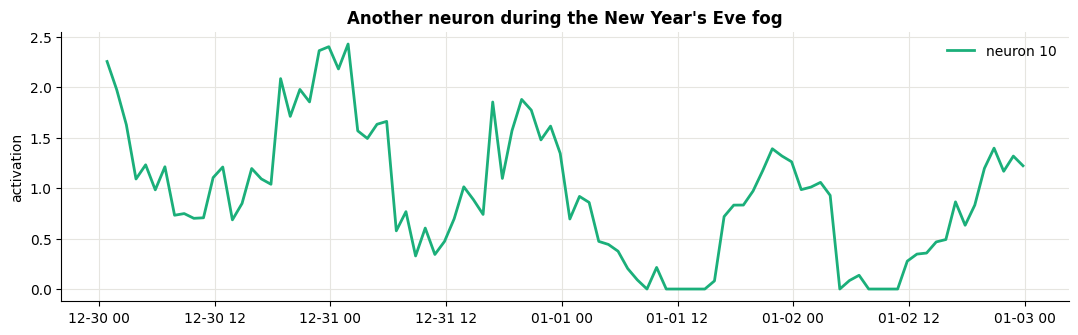

In [12]:
# 🧑‍💻 OPTIONAL CHALLENGE — SOLUTION
other = 9                                                    # neuron 10 (Python counts from 0)
print(pd.DataFrame({"input": READABLE, "weight": W1[other].round(2)}))   # its weights

plt.figure(figsize=(13, 3.5))                                # new figure
plt.plot(night.index, night_layer1[:, other], color=PALETTE[2], label="neuron " + str(other + 1))   # its activation
plt.ylabel("activation")                                     # axis label
plt.title("Another neuron during the New Year's Eve fog")    # title
plt.legend()                                                 # legend
plt.show()                                                   # display

## 4 · What did training change?
The same network *before* training has random weights. Let's ask it about the same hour, and about all of 2025.

Our hour — untrained network: 0.52  trained network: 0.572


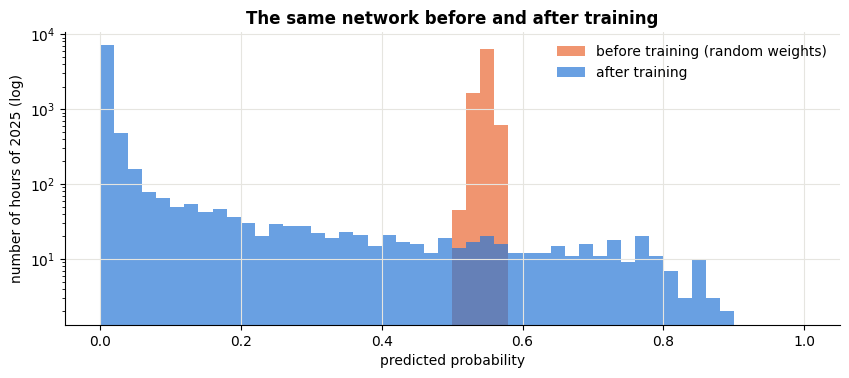

In [13]:
torch.manual_seed(0)                               # a fixed random start
untrained = lowvis_core.FogNet()                   # a network with the same structure, but random weights
untrained.eval()                                   # evaluation mode

X_test = torch.tensor(saved.scale(test))           # the scaled inputs of every hour of 2025
with torch.no_grad():                              # prediction only
    p_untrained = torch.sigmoid(untrained(X_test)).numpy()   # probabilities of the untrained network
p_trained = saved.probability(test)                # probabilities of the trained network

hour_row = saved.scale(raw_inputs)                 # the scaled inputs of our hour
with torch.no_grad():                              # prediction only
    p_hour_untrained = float(torch.sigmoid(untrained(torch.tensor(hour_row)))[0])   # untrained answer for our hour
print("Our hour — untrained network:", round(p_hour_untrained, 3),
      " trained network:", round(float(saved.probability(raw_inputs)[0]), 3))   # compare the two answers

plt.figure(figsize=(10, 3.8))                      # new figure
plt.hist(p_untrained, bins=50, range=(0, 1), color=PALETTE[1], alpha=0.7, label="before training (random weights)")   # untrained
plt.hist(p_trained, bins=50, range=(0, 1), color=PALETTE[0], alpha=0.7, label="after training")   # trained
plt.yscale("log")                                  # log scale
plt.xlabel("predicted probability")                # axis label
plt.ylabel("number of hours of 2025 (log)")        # axis label
plt.title("The same network before and after training")   # title
plt.legend()                                       # legend
plt.show()                                         # display

📖 **Reading:** before training the network answers roughly the same thing for every hour — it knows nothing. After training most hours get a probability close to 0
and a few get high values. **Training did nothing but change the ~430 numbers** we drew in §1.

---
# Part B — Why did the model say that? (explainability)

## 5 · Which inputs matter most?
We **shuffle** one input over all the hours of 2025 — its values stay realistic, but they no longer belong to the right hour — and count how many of the
**low-visibility cases the model was catching are now lost**. Hour and month are shuffled as pairs (sine and cosine together).

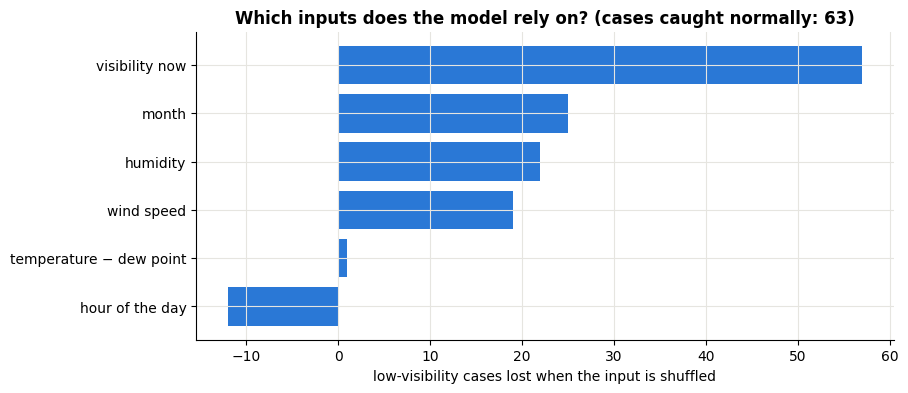

In [14]:
groups = {                                         # the inputs, grouped as people think about them
    "visibility now": ["vis_m"],                   # group name: the input column(s) it contains
    "temperature − dew point": ["spread_c"],       # one column
    "humidity": ["rh"],                            # one column
    "wind speed": ["wind_kt"],                     # one column
    "hour of the day": ["hour_sin", "hour_cos"],   # two columns: the hour on its circle
    "month": ["month_sin", "month_cos"],           # two columns: the month on its circle
}                                                  # (end of the groups)

truth = test["target"].values                      # what really happened in 2025


def count_hits(table):                             # number of low-visibility cases caught by the model on a table of hours
    alerts = saved.probability(table) >= saved.threshold   # alerts
    return int(np.sum(alerts & (truth == 1)))      # alert and low visibility = a hit


normal = count_hits(test)                          # hits with the real inputs
rng = np.random.default_rng(42)                    # random-number generator with a fixed seed
lost = {}                                          # hits lost for each group
for group_name in groups:                          # for each group of inputs...
    shuffled = test.copy()                         # ...copy the table of 2025...
    order = rng.permutation(len(shuffled))         # ...draw a random order of the hours...
    for column in groups[group_name]:              # ...and for each column of the group...
        shuffled[column] = shuffled[column].values[order]   # ...shuffle it (same order for sine and cosine)
    lost[group_name] = normal - count_hits(shuffled)   # cases no longer caught without this information

importance = pd.Series(lost).sort_values()         # sort from least to most important
plt.figure(figsize=(9, 4))                         # new figure
plt.barh(importance.index, importance.values, color=PALETTE[0])   # one bar per group
plt.xlabel("low-visibility cases lost when the input is shuffled")   # axis label
plt.title("Which inputs does the model rely on? (cases caught normally: " + str(normal) + ")")   # title
plt.show()                                         # display

📖 **Reading:**
- The longer the bar, the more the model depends on that input to catch low-visibility cases: **current visibility** comes first by far (fog persists), then month, humidity and wind.
- **Temperature − dew point** is almost ignored: the model gets the same information from humidity (we will see it again in the what-if curves).
- A **negative** bar (here the hour) means that with shuffled hours the model catches *more* cases — because it raises more alerts at random times, i.e. many more false alarms.
  This measure only counts caught cases, so always look at it together with the false alarms.

## 6 · What-if curves
We start from our hour (31 Dec 2022, 20:50) and change **one input at a time**, keeping the others fixed, to see how the probability reacts.

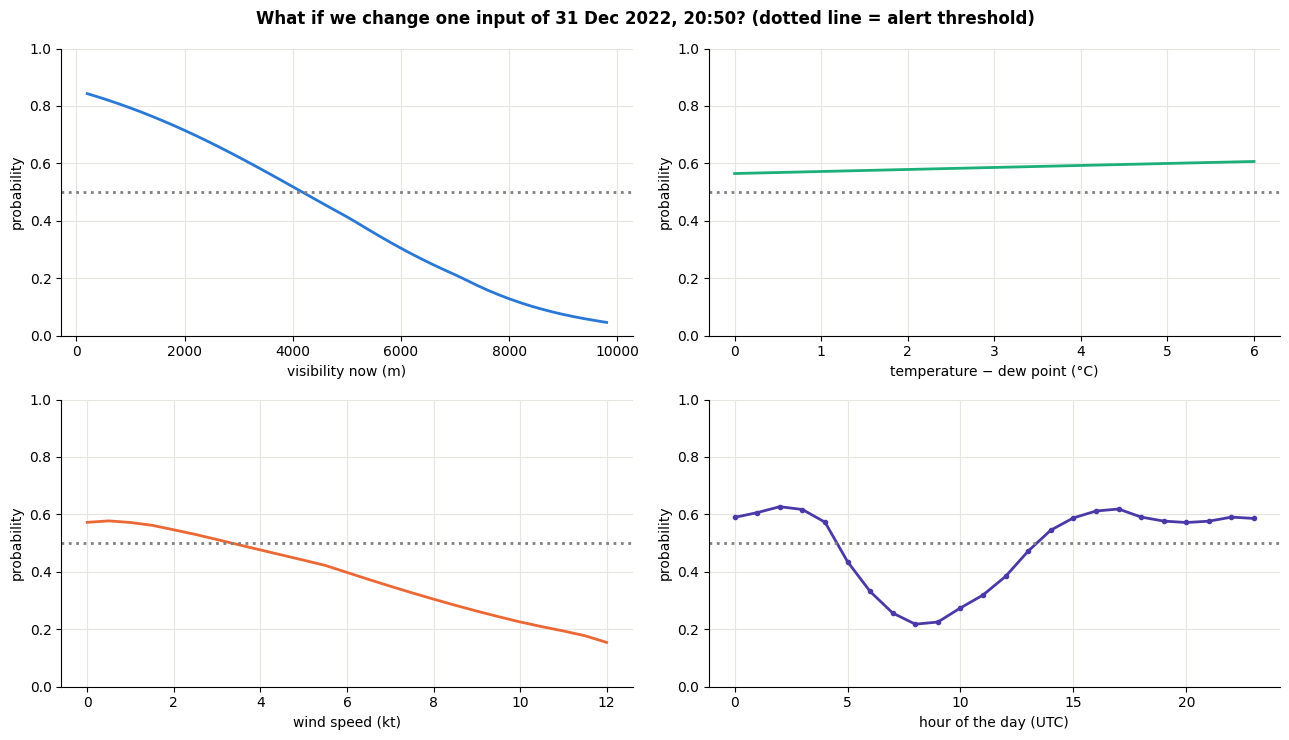

In [15]:
def what_if(column, values):                       # probabilities when one input takes each of the given values
    probabilities = []                             # the results
    for value in values:                           # for each value to try...
        changed = raw_inputs.copy()                # ...copy our hour...
        changed[column] = value                    # ...change one input...
        probabilities.append(float(saved.probability(changed)[0]))   # ...and ask the model
    return probabilities                           # give the list back


def what_if_hour(hours):                           # the same for the hour of the day (sine and cosine together)
    probabilities = []                             # the results
    for h in hours:                                # for each hour to try...
        changed = raw_inputs.copy()                # ...copy our hour...
        changed["hour_sin"] = np.sin(2 * np.pi * h / 24)   # ...set the hour (sine)...
        changed["hour_cos"] = np.cos(2 * np.pi * h / 24)   # ...and (cosine)...
        probabilities.append(float(saved.probability(changed)[0]))   # ...and ask the model
    return probabilities                           # give the list back


visibilities = np.arange(200, 10000, 200)          # visibilities to try (m)
spreads = np.arange(0, 6.1, 0.25)                  # temperature − dew point values to try (°C)
winds = np.arange(0, 12.5, 0.5)                    # wind speeds to try (kt)
hours = np.arange(0, 24)                           # hours to try

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))  # four plots
axes[0, 0].plot(visibilities, what_if("vis_m", visibilities), color=PALETTE[0])       # effect of visibility
axes[0, 0].set_xlabel("visibility now (m)")        # label
axes[0, 1].plot(spreads, what_if("spread_c", spreads), color=PALETTE[2])              # effect of saturation
axes[0, 1].set_xlabel("temperature − dew point (°C)")   # label
axes[1, 0].plot(winds, what_if("wind_kt", winds), color=PALETTE[1])                   # effect of wind
axes[1, 0].set_xlabel("wind speed (kt)")           # label
axes[1, 1].plot(hours, what_if_hour(hours), color=PALETTE[6], marker="o", markersize=3)   # effect of the hour
axes[1, 1].set_xlabel("hour of the day (UTC)")     # label
for ax in axes.flatten():                          # for each of the four plots...
    ax.axhline(saved.threshold, color="grey", linestyle=":")   # ...the alert threshold
    ax.set_ylim(0, 1)                              # ...probability axis from 0 to 1
    ax.set_ylabel("probability")                   # ...axis label
fig.suptitle("What if we change one input of 31 Dec 2022, 20:50? (dotted line = alert threshold)", fontweight="bold")   # title
plt.tight_layout()                                 # adjust spacing
plt.show()                                         # display

📖 **Reading:** each curve shows how the model reacts to one input, all else being equal.
Check each one against your own knowledge: does the risk rise when visibility falls? when the air gets closer to saturation? when the wind drops? at night?
**Where a curve contradicts meteorology, the model has learned a correlation from the data, not the physics.**
Look in particular at temperature − dew point: the curve is almost flat (and even rises slightly for drier air). The model gets the saturation information from **humidity**
instead — the two inputs carry almost the same information, and the model has chosen to rely on one of them.

### 🧑‍💻 Optional coding challenge — the humidity curve
*Optional, for those who want to write code.*

**Task:** draw the what-if curve for **humidity** (from 60 % to 100 %), using the function `what_if` above.

Solution: `solutions/2S-2_inside_the_model_SOLUTIONS.ipynb`

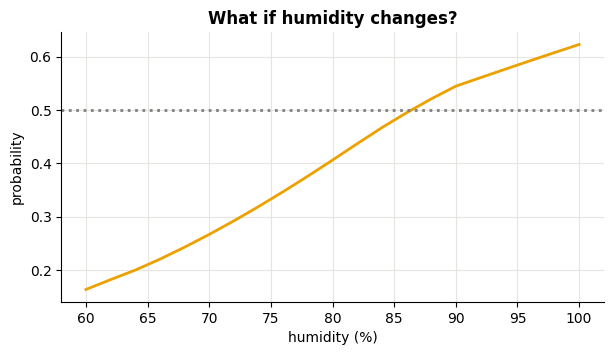

In [16]:
# 🧑‍💻 OPTIONAL CHALLENGE — SOLUTION
humidities = np.arange(60, 101, 2)                           # humidity values to try (%)
probabilities = what_if("rh", humidities)                    # the model's answers

plt.figure(figsize=(7, 3.5))                                 # new figure
plt.plot(humidities, probabilities, color=PALETTE[3])        # the curve
plt.axhline(saved.threshold, color="grey", linestyle=":")    # the alert threshold
plt.xlabel("humidity (%)")                                   # horizontal axis label
plt.ylabel("probability")                                    # vertical axis label
plt.title("What if humidity changes?")                       # title
plt.show()                                                   # display

## 7 · Explaining one single alert
For one hour, we take each input in turn and **replace it with its value from 300 other, randomly chosen hours** (of the training years), keeping all the other inputs.
The average probability we get tells us what the model would say *without knowing that input*.
- If the probability **drops** without the input, that input was **pushing towards an alert** (red bar).
- If it **rises**, that input was **holding the alert back** (blue bar).

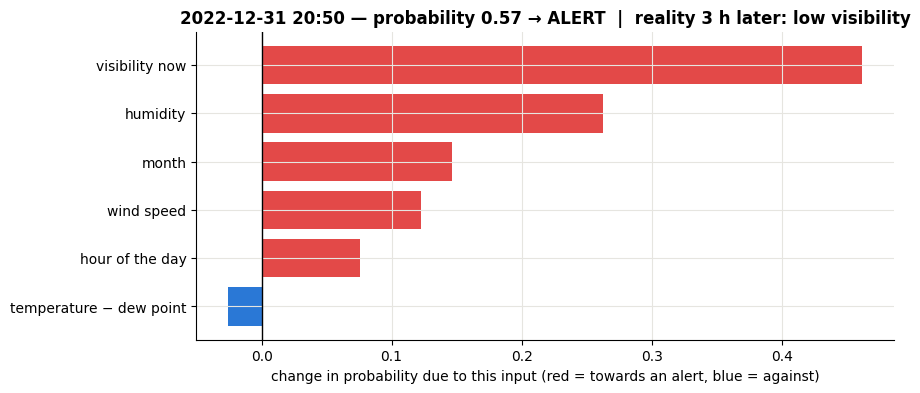

Inputs of this hour:
                      vis_m  spread_c    rh  wind_kt
valid                                               
2022-12-31 20:50:00  3492.3       1.0  93.4      1.0


In [17]:
training_hours = features[features.index < "2024-01-01"].dropna()   # the inputs of the training years
references = training_hours.sample(300, random_state=1)            # 300 randomly chosen reference hours


def explain_hour(hour):                            # explains the model's answer for one hour of the data
    row = features.loc[[hour]]                     # the 8 inputs of that hour
    p_real = float(saved.probability(row)[0])      # the model's probability with the real inputs
    effects = {}                                   # how much each group of inputs moves the probability
    for group_name in groups:                      # for each group of inputs...
        copies = pd.concat([row] * len(references))   # ...300 copies of our hour...
        for column in groups[group_name]:          # ...in which the columns of this group...
            copies[column] = references[column].values   # ...take the values of the 300 reference hours
        p_without = float(saved.probability(copies).mean())   # average probability without this information
        effects[group_name] = p_real - p_without   # positive = this input pushed the probability up

    effects = pd.Series(effects).sort_values()     # sort the effects
    colours = []                                   # one colour per bar
    for value in effects.values:                   # for each effect...
        if value > 0:                              # ...pushing towards an alert...
            colours.append(PALETTE[7])             # ...red
        else:                                      # ...holding the alert back...
            colours.append(PALETTE[0])             # ...blue

    if p_real >= saved.threshold:                  # the model's decision...
        decision = "ALERT"                         # ...alert
    else:                                          # ...or...
        decision = "no alert"                      # ...no alert
    truth_value = "unknown"                        # what really happened 3 hours later
    if hour in dataset.index:                      # if we know it...
        if dataset.loc[hour, "target"] == 1:       # ...low visibility...
            truth_value = "low visibility"         # reality: low visibility 3 hours later
        else:                                      # ...or not
            truth_value = "no low visibility"      # reality: no low visibility

    plt.figure(figsize=(9, 4))                     # new figure
    plt.barh(effects.index, effects.values, color=colours)   # one bar per input group
    plt.axvline(0, color="black", linewidth=1)     # the zero line
    plt.xlabel("change in probability due to this input (red = towards an alert, blue = against)")   # axis label
    plt.title(str(hour) + " — probability " + str(round(p_real, 2)) + " → " + decision + "  |  reality 3 h later: " + truth_value)   # title
    plt.show()                                     # display
    print("Inputs of this hour:")                  # show the raw inputs too
    print(row[["vis_m", "spread_c", "rh", "wind_kt"]].round(1).to_string())   # the four weather inputs


explain_hour("2022-12-31 20:50")                   # explain our example hour

📖 **Reading:** the red bars show what pushed the model towards an alert for 20:50 on New Year's Eve, the blue bars what held it back.
Compare them with the inputs printed below the chart (visibility already reduced to 3 500 m, humidity above 90 %, almost no wind).
A chart like this is what an operational user would need, next to the alert, to judge whether to trust it.

⚠️ These explanations describe **the model**, not the weather: they tell us what the model *uses*, which may differ from the true physical causes.

---
## 8 · Your task: be the analyst
Below is a list of real hours of **2025** (the test year) where the model was **right**, raised a **false alarm**, or **missed** a low-visibility event.

In [18]:
probabilities_2025 = saved.probability(test)                  # the model's probability for every hour of 2025
alerts_2025 = probabilities_2025 >= saved.threshold           # its alerts
hits = test.index[alerts_2025 & (truth == 1)]                 # alert and low visibility 3 h later
false_alarms = test.index[alerts_2025 & (truth == 0)]         # alert but no low visibility
misses = test.index[(~alerts_2025) & (truth == 1)]            # no alert but low visibility

lists = {"HITS": hits, "FALSE ALARMS": false_alarms, "MISSES": misses}   # the three lists, by name
for name in lists:                                            # for each list...
    print(name + ":")                                         # ...print its name...
    step = max(1, len(lists[name]) // 4)                      # ...spread the examples over the year...
    for moment in lists[name][::step][:4]:                    # ...and show 4 of its times
        print("   ", moment)                                  # one time per line

HITS:
    2025-01-05 19:50:00
    2025-01-25 13:50:00
    2025-02-25 13:50:00
    2025-11-15 16:50:00
FALSE ALARMS:
    2025-01-02 16:50:00
    2025-01-23 04:50:00
    2025-02-12 21:50:00
    2025-12-01 14:50:00
MISSES:
    2025-01-04 00:50:00
    2025-02-11 04:50:00
    2025-02-25 09:50:00
    2025-10-23 06:50:00


**Task (no coding needed):**
1. Copy one of the times above into the cell below, between the quotes, and run it. Try at least **one hit, one false alarm and one miss**.
2. For each one, answer:
   - Which inputs pushed the model towards an alert, and which held it back?
   - Does this reasoning make sense to you, as an aviation professional?
   - For the false alarm and the miss: can you see *why* the model got it wrong?
   - Would you trust this alert in operations? What else would you want to know?

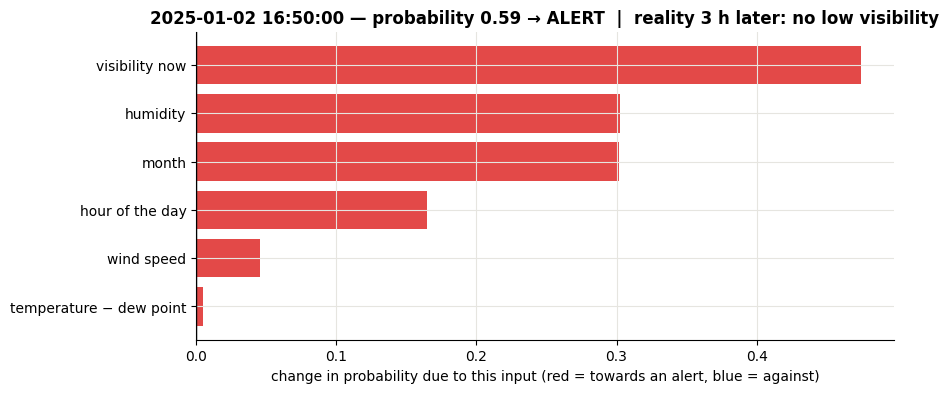

Inputs of this hour:
                      vis_m  spread_c    rh  wind_kt
valid                                               
2025-01-02 16:50:00  4007.3       1.0  93.2      1.0


In [19]:
CHOSEN_HOUR = str(false_alarms[0])                 # ← replace with a time from the lists above, e.g. "2025-01-05 02:50:00"
explain_hour(CHOSEN_HOUR)                          # explain the model's answer for that hour

---
## 9 · Questions for discussion
1. The whole model is about 430 numbers, and we can see all of them. Why is that **not enough** to understand it?
2. The explanations tell us what the model *uses*. Is a model we can explain automatically a model we can **trust**?
3. What would a supervisor or an airport operator need to see, next to an alert, before acting on it?
4. Our target is a **proxy** for LVP. Does that change how you would explain the model's alerts to an operational user?

➡️ **Next: Part 3 — turning the model into a small service.**